<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_09_3_reality_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# T81-558: Applications of Deep Neural Networks

**Module 10: Facial Processing**

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 10 Material

- Part 10.1: Detecting Faces in an Image [[Video]]() [[Notebook]](t81_558_class_10_1_faces.ipynb)
- Part 10.2: Detecting Facial Features [[Video]]() [[Notebook]](t81_558_class_10_2_face_landmarks.ipynb)
- **Part 10.3: Reality Augmentation** [[Video]]() [[Notebook]](t81_558_class_10_3_reality_augmentation.ipynb)
- Part 10.4: Application: Emotion Detection [[Video]]() [[Notebook]](t81_558_class_10_4_emotion.ipynb)
- Part 10.5: Dynaface [[Video]]() [[Notebook]](t81_558_class_10_5_dynaface.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is and sets up the correct hardware settings for PyTorch.


In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

!pip install -q mediapipe opencv-python matplotlib requests

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_available()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: using Google CoLab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.3 MB/s eta 0:00:00
Using device: cuda


# Part 10.3: Reality Augmentation

In Part 10.2 we used MediaPipe's Face Landmarker to extract a 478-point mesh from a face. Those points are useful on their own, but they really start to pay off when we use them as anchors for *augmentation*: drawing virtual content on top of the face that follows its geometry. This is the technique behind every AR filter you have ever seen, from Snapchat masks to virtual try-on for glasses, makeup, and hairstyles, to the avatar effects in video conferencing apps.

The general recipe is always the same:

1. Detect the face and its landmarks.
2. Pick the landmarks that correspond to the feature you want to augment (the eyes for glasses, the lips for lipstick, the cheeks for blush, the head pose for a hat).
3. Use those landmark coordinates to size, position, and orient the overlay.
4. Composite the overlay onto the original image.

The previous version of this notebook used a stack of three different libraries (MTCNN for face detection, SPIGA for landmarks, OpenCV for drawing) and required a CUDA GPU. This version uses MediaPipe end to end, which is faster to set up, runs on CPU, and gives us iris landmarks for free. Iris landmarks are particularly useful for glasses because they tell us exactly where the center of each lens should sit.

In this notebook we will draw a simple pair of eyeglasses on a face. We use:

* The iris center landmarks (indices 468 and 473) to locate the center of each lens.
* The eye corner landmarks (33, 133, 362, 263) to size each lens based on eye width.
* A line drawn between the two inner eye corners (133 and 362) as the bridge of the glasses.

The result is a deliberately schematic pair of glasses, but the same anchor-and-overlay pattern extends directly to compositing a real PNG of glasses onto the face.


## Configuration

As in Part 10.2, we collect the tunable values up front. The MediaPipe model URL and target image width are the same; the new constants here are the landmark indices we need for the glasses overlay and a few drawing parameters.

The landmark indices come from the canonical MediaPipe face mesh:

* `LEFT_IRIS_CENTER = 468` and `RIGHT_IRIS_CENTER = 473` are the centers of the iris on each eye. These exist only when iris refinement is enabled, which the `face_landmarker.task` model does by default.
* `LEFT_EYE_INNER` and `LEFT_EYE_OUTER` (and the right-eye equivalents) bracket each eye. The distance between inner and outer gives a natural sizing for the lens radius. The two inner corners also serve as the endpoints of the bridge.

Note on naming: MediaPipe uses the subject's anatomical left and right, not the viewer's. From the camera's perspective, the subject's left eye is on the right side of the image. The constants here follow MediaPipe's convention.


In [2]:
# =========================
# Constants
# =========================

IMAGE_URL = "https://data.heatonresearch.com/images/jeff/about-jeff-heaton-2020.jpg"

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
)

MODEL_PATH = "face_landmarker.task"

TARGET_WIDTH = 1024
NUM_FACES = 1

# MediaPipe face mesh landmark indices.
# Anatomical left and right (the subject's left is on the viewer's right).
LEFT_IRIS_CENTER = 468
RIGHT_IRIS_CENTER = 473
LEFT_EYE_INNER = 362            # inner corner of the subject's left eye
LEFT_EYE_OUTER = 263            # outer corner of the subject's left eye
RIGHT_EYE_INNER = 133           # inner corner of the subject's right eye
RIGHT_EYE_OUTER = 33            # outer corner of the subject's right eye

# Drawing parameters for the glasses overlay
GLASSES_COLOR = (255, 0, 0)     # red, in RGB
GLASSES_THICKNESS = 5
LENS_RADIUS_SCALE = 0.65        # lens radius as a fraction of the eye-corner distance

## Imports and helper functions

The supporting code mirrors Part 10.2: download the model, fetch and resize the image, build a detector, and display the result. The new helper here is `draw_glasses`, which uses the landmark indices defined above to compute lens centers, lens sizes, and the bridge line.

A few things worth noting:

* `draw_glasses` works in pixel coordinates. MediaPipe returns normalized coordinates in `[0, 1]`, so we multiply by image width and height to get pixels. We do this conversion once into a NumPy array of shape `(478, 2)` so the rest of the function can index into it cleanly.
* The lens radius is computed from the distance between the two corners of each eye, scaled by `LENS_RADIUS_SCALE`. This makes the glasses size automatically with the face, regardless of how big the input image is or how zoomed in the subject is.
* We draw circles for the lenses rather than ellipses. With reliable landmarks for both the iris center and the eye corners, a circle sized off the eye width looks natural without needing to track the headpose explicitly. If you want oriented ellipses that follow head tilt, you would compute the angle between the two iris centers and pass it as the rotation parameter to `cv2.ellipse`.


In [3]:
# =========================
# Imports
# =========================

import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# =========================
# Helper functions
# =========================

def download_file(url, path):
    response = requests.get(url)
    response.raise_for_status()

    with open(path, "wb") as f:
        f.write(response.content)


def load_image_from_url(url):
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()

    image_array = np.frombuffer(response.content, np.uint8)
    bgr = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if bgr is None:
        raise ValueError("Could not decode image. Try a direct JPG or PNG URL.")

    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def resize_to_width(rgb, target_width):
    h, w, _ = rgb.shape

    if w == target_width:
        return rgb

    scale = target_width / w
    new_h = int(h * scale)

    return cv2.resize(rgb, (target_width, new_h), interpolation=cv2.INTER_LINEAR)


def create_face_landmarker(model_path):
    base_options = python.BaseOptions(model_asset_path=model_path)

    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=NUM_FACES,
    )

    return vision.FaceLandmarker.create_from_options(options)


def landmarks_to_pixels(face_landmarks, width, height):
    """Convert a list of normalized landmarks to an (N, 2) pixel array."""
    return np.array(
        [[lm.x * width, lm.y * height] for lm in face_landmarks],
        dtype=np.float32,
    )


def draw_glasses(rgb, points):
    annotated = rgb.copy()

    left_center = points[LEFT_IRIS_CENTER]
    right_center = points[RIGHT_IRIS_CENTER]

    left_inner = points[LEFT_EYE_INNER]
    left_outer = points[LEFT_EYE_OUTER]
    right_inner = points[RIGHT_EYE_INNER]
    right_outer = points[RIGHT_EYE_OUTER]

    left_radius = int(np.linalg.norm(left_inner - left_outer) * LENS_RADIUS_SCALE)
    right_radius = int(np.linalg.norm(right_inner - right_outer) * LENS_RADIUS_SCALE)

    cv2.circle(
        annotated,
        tuple(left_center.astype(int)),
        left_radius,
        GLASSES_COLOR,
        GLASSES_THICKNESS,
    )

    cv2.circle(
        annotated,
        tuple(right_center.astype(int)),
        right_radius,
        GLASSES_COLOR,
        GLASSES_THICKNESS,
    )

    # The bridge runs between the inner corners of the eyes,
    # not across the lens centers.
    cv2.line(
        annotated,
        tuple(right_inner.astype(int)),
        tuple(left_inner.astype(int)),
        GLASSES_COLOR,
        GLASSES_THICKNESS,
    )

    return annotated


def display_image(rgb):
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.axis("off")
    plt.show()

## Running the augmentation

The pipeline below is short because all the heavy lifting is in the helpers. We download the model file once, fetch and resize the image, run landmark detection, convert the landmarks to pixel coordinates, and pass them to `draw_glasses`.

Compare this to the original SPIGA-based version: there is no separate face detection step (MediaPipe handles it internally), no manual bounding-box construction, no model-config object, and no GPU requirement. The whole augmentation is one pass through MediaPipe and a handful of OpenCV draw calls.

If the detector returns no faces, the code raises a clear error rather than silently producing a blank overlay. In a real application you would also want to handle the multi-face case by looping over `result.face_landmarks`.


Resized image shape: (1024, 1024, 3)


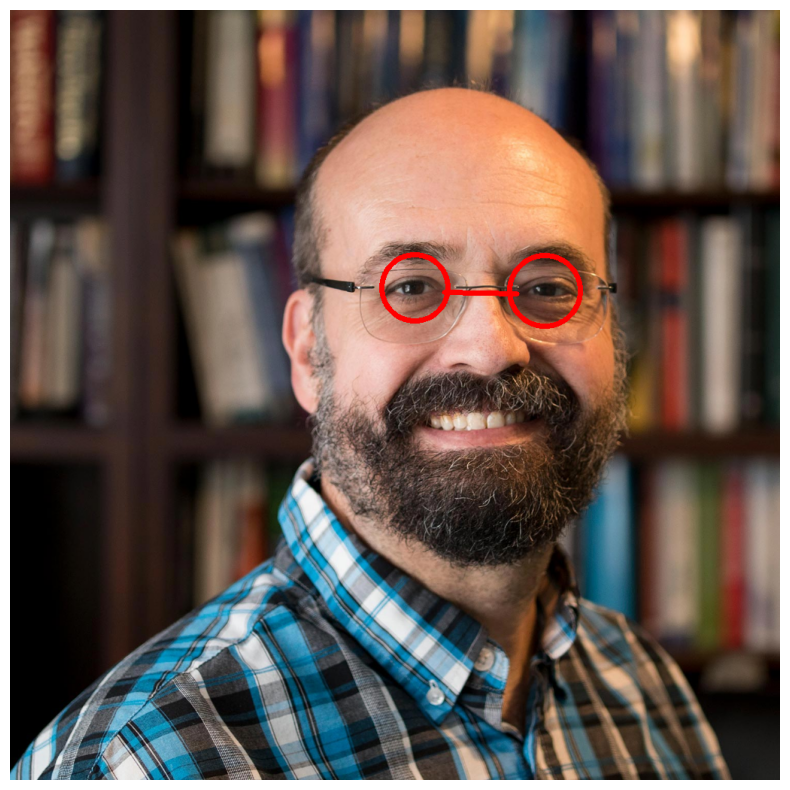

Detected faces: 1
Landmarks on first face: 478


In [4]:
# =========================
# Run augmentation
# =========================

download_file(MODEL_URL, MODEL_PATH)

rgb = load_image_from_url(IMAGE_URL)
rgb = resize_to_width(rgb, TARGET_WIDTH)

print(f"Resized image shape: {rgb.shape}")

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb,
)

detector = create_face_landmarker(MODEL_PATH)
result = detector.detect(mp_image)

if not result.face_landmarks:
    raise RuntimeError("No face detected. Try a different image.")

height, width, _ = rgb.shape
points = landmarks_to_pixels(result.face_landmarks[0], width, height)

annotated = draw_glasses(rgb, points)
display_image(annotated)

print(f"Detected faces: {len(result.face_landmarks)}")
print(f"Landmarks on first face: {len(result.face_landmarks[0])}")

## Going further

The glasses we drew are intentionally schematic. The same landmark-driven pipeline supports much richer effects:

* **Real glasses overlay**: Replace the circle and line drawing with a transparent PNG of glasses, warped so its anchor points (the centers of the two lenses) align with the iris centers. `cv2.warpAffine` or `cv2.getPerspectiveTransform` will handle the geometry.
* **Headpose-aware orientation**: MediaPipe can return a 4x4 facial transformation matrix when `output_facial_transformation_matrixes=True`. With that, you can rotate the overlay so it follows head tilt and yaw rather than always being axis-aligned.
* **Other features**: Lipstick uses the inner and outer lip contours. Blush uses the cheek region. A virtual hat uses the top-of-forehead landmarks plus the headpose matrix. The pattern is always the same: pick the right anchors, compute a transform, composite the overlay.
* **Video**: For real-time AR, swap the static image for a webcam feed and call `detector.detect_for_video` on each frame. MediaPipe is designed for this and runs comfortably on CPU at 30 FPS for a single face.

In Part 10.4 we move from drawing on top of the face to interpreting it: using the same landmarks (and optionally the blendshape outputs) to classify emotion.
